### Import libraries

In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [3]:
df = pd.read_csv(
    "ecommerce.csv",
    encoding="latin1",
    low_memory=False
)

print(df)

         ï»¿Order ID Order Date Ship Date  Aging       Ship Mode  \
0          AU-2015-1    11/9/15  11/17/15    8.0     First Class   
1          AU-2015-2    6/30/15    7/2/15    2.0     First Class   
2          AU-2015-3    12/5/15  12/13/15    8.0     First Class   
3          AU-2015-4     5/9/15   5/16/15    7.0     First Class   
4          AU-2015-5     7/9/15   7/18/15    9.0     First Class   
...              ...        ...       ...    ...             ...   
51285  FA-2015-30771    1/21/15   1/27/15    6.0  Standard Class   
51286  FA-2015-30772    6/22/15   6/24/15    2.0  Standard Class   
51287  FA-2015-30773     1/1/15    1/7/15    6.0  Standard Class   
51288  FA-2015-30774    12/7/15  12/14/15    7.0  Standard Class   
51289  FA-2015-30775    12/1/15   12/6/15    5.0  Standard Class   

         Product Category            Product     Sales Quantity Discount  ...  \
0      Auto & Accessories  Car Media Players  $140.00         2     0.05  ...   
1      Auto & Accesso

### Checking Columns 

In [4]:
df.columns

Index(['ï»¿Order ID', 'Order Date', 'Ship Date', 'Aging', 'Ship Mode',
       'Product Category', 'Product', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority', 'Customer ID',
       'Customer Name', 'Segment', 'City', 'State', 'Country', 'Region',
       'Months'],
      dtype='str')

### Renaming Column

In [5]:
df.rename(columns={"ï»¿Order ID":"Order ID"}, inplace=True)

In [6]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Aging', 'Ship Mode',
       'Product Category', 'Product', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority', 'Customer ID',
       'Customer Name', 'Segment', 'City', 'State', 'Country', 'Region',
       'Months'],
      dtype='str')

### Convert Dates

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

C:\Users\mamat\AppData\Local\Temp\ipykernel_19356\2772104420.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"])
C:\Users\mamat\AppData\Local\Temp\ipykernel_19356\2772104420.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"])


In [8]:
df["Order Date"].head(10)

0   2015-11-09
1   2015-06-30
2   2015-12-05
3   2015-05-09
4   2015-07-09
5   2015-02-25
6   2015-04-09
7   2015-03-30
8   2015-02-09
9   2015-04-21
Name: Order Date, dtype: datetime64[us]

In [9]:
df["Ship Date"].head(12)

0    2015-11-17
1    2015-07-02
2    2015-12-13
3    2015-05-16
4    2015-07-18
5    2015-03-05
6    2015-04-10
7    2015-04-06
8    2015-02-16
9    2015-05-01
10   2015-11-26
11   2015-09-02
Name: Ship Date, dtype: datetime64[us]

### Check dataset

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          51290 non-null  str           
 1   Order Date        51289 non-null  datetime64[us]
 2   Ship Date         51290 non-null  datetime64[us]
 3   Aging             51289 non-null  float64       
 4   Ship Mode         51290 non-null  str           
 5   Product Category  51290 non-null  str           
 6   Product           51290 non-null  str           
 7   Sales             51290 non-null  str           
 8   Quantity          51289 non-null  str           
 9   Discount          51290 non-null  str           
 10  Profit            51290 non-null  str           
 11  Shipping Cost     51290 non-null  str           
 12  Order Priority    51288 non-null  str           
 13  Customer ID       51289 non-null  str           
 14  Customer Name     51290 non-null 

In [11]:
print(df["Sales"].head())
print(df["Profit"].head())
print(df["Shipping Cost"].head())
print(df["Discount"].head())
print(df["Quantity"].head())

0    $140.00 
1    $211.00 
2    $117.00 
3    $118.00 
4    $250.00 
Name: Sales, dtype: str
0     $46.00 
1    $112.00 
2     $31.20 
3     $26.20 
4    $160.00 
Name: Profit, dtype: str
0     $4.60 
1    $11.20 
2     $3.10 
3     $2.60 
4    $16.00 
Name: Shipping Cost, dtype: str
0    0.05
1    0.03
2    0.01
3    0.05
4    0.04
Name: Discount, dtype: str
0    2
1    3
2    5
3    2
4    1
Name: Quantity, dtype: str


### Clean currency columns

In [15]:
for col in ["Sales", "Profit", "Shipping Cost"]:
    print(f"\nChecking {col}")
    print(df[df[col].str.contains("[a-zA-Z]", regex=True, na=False)][col].unique())


Checking Sales


AttributeError: Can only use .str accessor with string values, not floating

In [16]:

money_cols = ["Sales", "Profit", "Shipping Cost"]

for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [17]:
print(df[["Sales", "Profit", "Shipping Cost"]].dtypes)

Sales            float64
Profit           float64
Shipping Cost    float64
dtype: object


### Checking 

In [18]:
df[df["Sales"].isna()]


,Order ID,Order Date,Ship Date,Aging,Ship Mode,Product Category,Product,Sales,Quantity,Discount,...,Shipping Cost,Order Priority,Customer ID,Customer Name,Segment,City,State,Country,Region,Months
793,AU-2015-794,2015-10-06,2015-10-12,6.0,First Class,Auto & Accessories,Car Speakers,NaN,3,0.01,...,12.5,Critical,RE-00794,Schwartz Laware,Consumer,Bandung,Jawa Barat,Indonesia,Southeast Asia,Oct


In [19]:
df[df["Shipping Cost"].isna()]

,Order ID,Order Date,Ship Date,Aging,Ship Mode,Product Category,Product,Sales,Quantity,Discount,...,Shipping Cost,Order Priority,Customer ID,Customer Name,Segment,City,State,Country,Region,Months
535,AU-2015-536,2015-03-21,2015-03-24,3.0,First Class,Auto & Accessories,Tyre,250.0,4,0.02,...,NaN,Critical,ON-00536,Webster Jordon,Consumer,Guiyang,Guizhou,China,North Asia,Mar


### Convert numeric columns

In [20]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")

### Droping those rows

In [21]:
df.dropna(subset=["Sales", "Shipping Cost"], inplace=True)

### Checking Nulls

In [22]:
df.isnull().sum()

Order ID            0
Order Date          1
Ship Date           0
Aging               1
Ship Mode           0
Product Category    0
Product             0
Sales               0
Quantity            2
Discount            1
Profit              0
Shipping Cost       0
Order Priority      2
Customer ID         1
Customer Name       0
Segment             1
City                0
State               0
Country             0
Region              1
Months              0
dtype: int64

### Remove rows with missing values

In [23]:
df.dropna(inplace=True)

### Reset index

In [24]:
df.reset_index(drop=True, inplace=True)

### Verify Missing Values

In [25]:
df.isnull().sum()

Order ID            0
Order Date          0
Ship Date           0
Aging               0
Ship Mode           0
Product Category    0
Product             0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
Customer ID         0
Customer Name       0
Segment             0
City                0
State               0
Country             0
Region              0
Months              0
dtype: int64

### Check duplicate rows

In [26]:
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  0


### Observation:
No duplicate rows were removed because duplicate transactions

### Verify final dataset

In [27]:

df.info()
df.shape
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 51278 entries, 0 to 51277
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          51278 non-null  str           
 1   Order Date        51278 non-null  datetime64[us]
 2   Ship Date         51278 non-null  datetime64[us]
 3   Aging             51278 non-null  float64       
 4   Ship Mode         51278 non-null  str           
 5   Product Category  51278 non-null  str           
 6   Product           51278 non-null  str           
 7   Sales             51278 non-null  float64       
 8   Quantity          51278 non-null  float64       
 9   Discount          51278 non-null  float64       
 10  Profit            51278 non-null  float64       
 11  Shipping Cost     51278 non-null  float64       
 12  Order Priority    51278 non-null  str           
 13  Customer ID       51278 non-null  str           
 14  Customer Name     51278 non-null 

Order ID            0
Order Date          0
Ship Date           0
Aging               0
Ship Mode           0
Product Category    0
Product             0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
Customer ID         0
Customer Name       0
Segment             0
City                0
State               0
Country             0
Region              0
Months              0
dtype: int64

Rule to remember
-

- Numeric column → df.plot(), sns.histplot(), sns.lineplot(), sns.scatterplot()
- Categorical column → value_counts().plot() or sns.countplot()

***Insight: 1***
-

Shows the different product categories and their order frequency.

In [28]:
# Find all Unique Product Categories
print(df["Product Category"].unique())

<StringArray>
['Auto & Accessories', 'Electronic', 'Home & Furniture', 'Fashion']
Length: 4, dtype: str


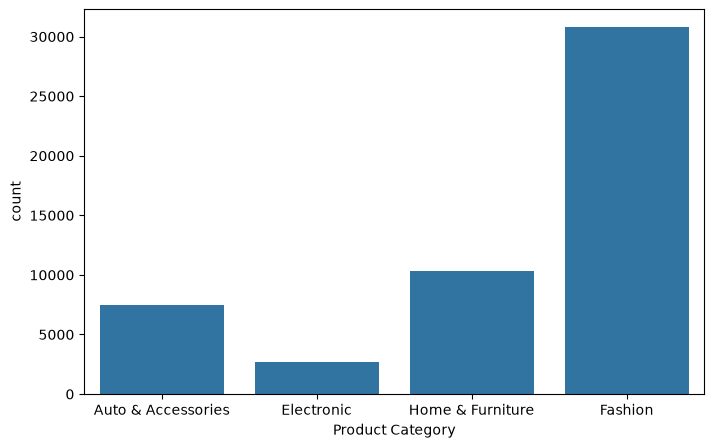

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Product Category",
    data=df
)

# plt.xticks(rotation=20)

plt.show()

***Insight: 2***
---

Identify the most frequently used shipping method.

In [30]:
# Find the Number of Orders for each Ship Mode
shipm = df["Ship Mode"].value_counts()
print(shipm)

Ship Mode
Standard Class    30775
Second Class      10309
First Class        7492
Same Day           2701
45788                 1
Name: count, dtype: int64


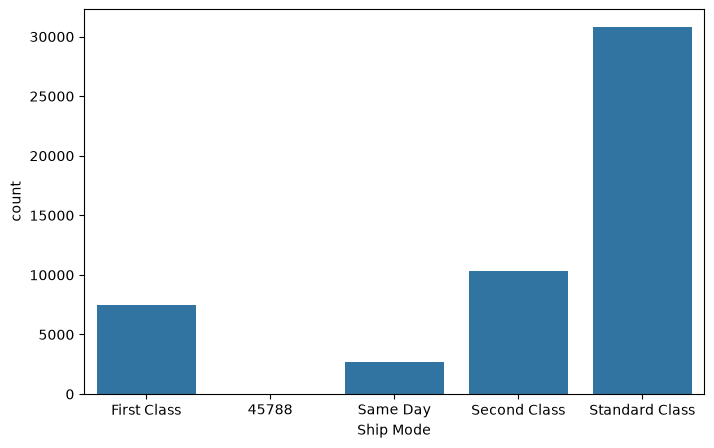

In [31]:

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Ship Mode")

plt.show()

***Insight: 3***
-

Identifies highly profitable orders.

In [32]:
# Find all Orders where Profit is greater than $150
print(df.loc[df["Profit"] > 150,
             ["Order ID", "Product", "Sales", "Profit"]])

            Order ID     Product  Sales  Profit
4          AU-2015-5        Tyre  250.0   160.0
30        AU-2015-32        Tyre  250.0   165.0
48        AU-2015-50        Tyre  250.0   165.0
57        AU-2015-59        Tyre  250.0   160.0
66        AU-2015-68        Tyre  250.0   167.5
...              ...         ...    ...     ...
51103  FA-2015-30601  T - Shirts  248.0   158.1
51125  FA-2015-30623  T - Shirts  248.0   155.6
51136  FA-2015-30634  T - Shirts  248.0   153.1
51158  FA-2015-30656  T - Shirts  248.0   160.6
51202  FA-2015-30700  T - Shirts  248.0   165.5

[1918 rows x 4 columns]


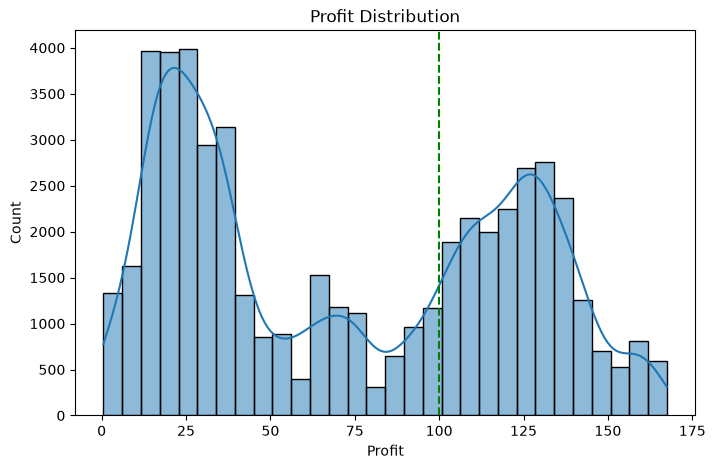

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Profit"],
    bins = 30,
    kde = True
)
plt.axvline(100, color = "green", linestyle = "--")
plt.title("Profit Distribution")
plt.show()

***Insight: 4***
-
Represents the average revenue generated per order.

In [34]:
#Find the Average Sales
avg_sales = df["Sales"].mean()
print("Average Sales: ",avg_sales)

Average Sales:  156.42749327196847


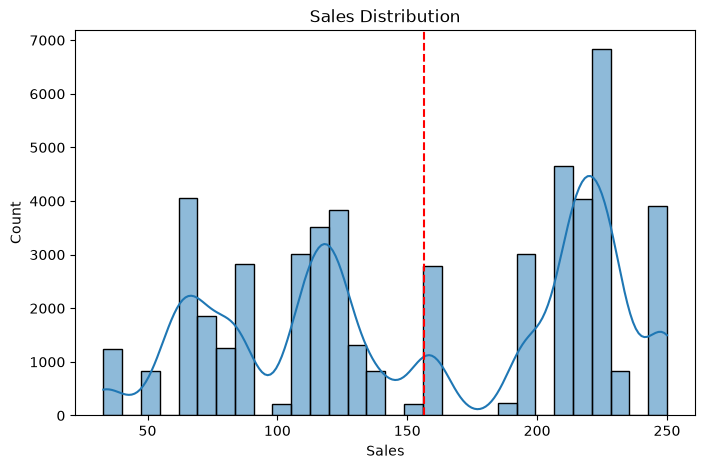

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Sales"],
    bins = 30,
    kde = True
)
plt.axvline(avg_sales, color = "red", linestyle = "--")
plt.title("Sales Distribution")
plt.show()

***Insight: 5***
-
Shows the highest shipping charge in the dataset.

In [36]:
#Find the Maximum Shipping Cost
print(df["Shipping Cost"].max())

16.8


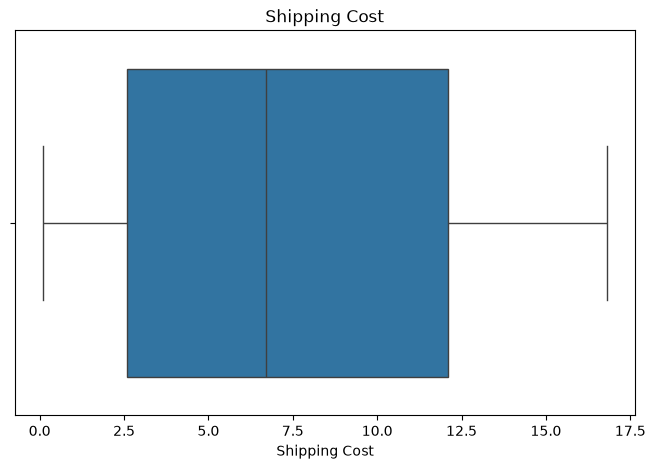

In [37]:
plt.figure(figsize = (8,5))
sns.boxplot(
    x = df["Shipping Cost"]
)
plt.title("Shipping Cost")
plt.show()